In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage, compute_gap_in_percentage_list, convert_to_dict_multiple_runs
from parse_levels import filter_folder_info
import pandas as pd
import matplotlib.ticker as ticker
from plot_utils import plot_gap_comparison
import re
import copy
import json

In [2]:
# for each item in the dict, if any two have the same 'record', remove the one with lower number of steps in metric
# def deduplicate_metrics(search_results):
#     records_length_so_far = {}
#     new_search_results = {}
#     for key, value in search_results.items():
#         if value['record'] not in records_length_so_far:
#             records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
#             new_search_results[key] = value
#         else:
#             if len(value['metrics']['step']) > records_length_so_far[value['record']][0]:
#                 new_search_results.pop(records_length_so_far[value['record']][1])

#                 records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
#                 new_search_results[key] = value
#     return new_search_results



In [ ]:
# ori_results = find_levels_in_configs_glob(
#     [
#         '/checkpoint/maui/zhaobc/scientist/workspace/record_*',
#     ]
# )
# with open('/checkpoint/maui/zhaobc/scientist/code_analysis_with_all_versions_knowledge_o3_mini.json', 'r') as f:
#     o3_results = json.load(f)


In [4]:
# with open('may8.cache', 'w') as f:
#     json.dump(ori_results, f)

In [5]:
with open('may8.cache', 'r') as f:
    ori_results = json.load(f)

In [6]:
# z_folder_info = filter_folder_info(ori_results, [('levels', 'z')])
unique_levels = set()
for key, value in ori_results.items():
    unique_levels.add(value['levels'][0])
unique_levels

{1, 12, 125, 129, 19, 2, 5, 'z'}

In [7]:
# 1 is psuedo-code
# 2 is text description
# 5 is paper like 
# 9 is adhoc knowledge, we can ignore it for now
# 'z' is zero knowledge

In [8]:
folder_info = ori_results
# o3_results

In [9]:
len(folder_info)

2378

In [21]:
# flat search -- n_initial_hypotheses = 50
flat_params = [
    ('runner', 'bon'),
    # ('n_initial_hypotheses', 50),
    ('n_iterations', 1),
]
# tree search -- n_initial_hypotheses = 1, n_hypotheses = 3
tree_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 1),
    ('n_hypotheses', 3),
]
# forest search -- n_initial_hypotheses = 3, n_hypotheses = 3
forest_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
]
# AIDE -- n_initial_hypotheses = 3, n_hypotheses = 1, debug_prob = 0.5
aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 1),
    ('debug_prob', 0.5),
]
# MultiAIDE -- n_initial_hypotheses = 3, n_hypotheses = 3, debug_prob = 0.5
multi_aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
    ('debug_prob', 0.5),
]

search_algo_params = {
    'flat': flat_params,
    'tree': tree_params,
    'forest': forest_params,
    'ori_aide': aide_params,
    'multi_aide': multi_aide_params,
}

plot_info = {}

for search_algo, params in search_algo_params.items():
    plot_info[search_algo] = {}
    for level in [1, 12, 125, 'z']:
        plot_info[search_algo][level] = {}
        for model in ['deepseek-r1', 'o3-mini']:
        # for model in ['o3-mini']:
            search_params = params + [('levels', level), ('model', model)]
            filtered_folder_info = filter_folder_info(folder_info, search_params)
            print(f'{search_algo} {level} {model} {len(filtered_folder_info)}')
            plot_info[search_algo][level][model] = filtered_folder_info



flat 1 deepseek-r1 31
flat 1 o3-mini 31
flat 12 deepseek-r1 51
flat 12 o3-mini 59
flat 125 deepseek-r1 55
flat 125 o3-mini 55
flat z deepseek-r1 20
flat z o3-mini 20
tree 1 deepseek-r1 18
tree 1 o3-mini 18
tree 12 deepseek-r1 38
tree 12 o3-mini 46
tree 125 deepseek-r1 55
tree 125 o3-mini 55
tree z deepseek-r1 20
tree z o3-mini 20
forest 1 deepseek-r1 18
forest 1 o3-mini 18
forest 12 deepseek-r1 35
forest 12 o3-mini 40
forest 125 deepseek-r1 70
forest 125 o3-mini 70
forest z deepseek-r1 20
forest z o3-mini 20
ori_aide 1 deepseek-r1 15
ori_aide 1 o3-mini 15
ori_aide 12 deepseek-r1 37
ori_aide 12 o3-mini 30
ori_aide 125 deepseek-r1 37
ori_aide 125 o3-mini 37
ori_aide z deepseek-r1 20
ori_aide z o3-mini 20
multi_aide 1 deepseek-r1 18
multi_aide 1 o3-mini 18
multi_aide 12 deepseek-r1 55
multi_aide 12 o3-mini 55
multi_aide 125 deepseek-r1 111
multi_aide 125 o3-mini 103
multi_aide z deepseek-r1 20
multi_aide z o3-mini 20


In [22]:
figure_data = {}
for search_algo in search_algo_params.keys():
    for level in [1, 12, 125, 'z']:
        # for model in ['o3-mini']:
        for model in ['deepseek-r1', 'o3-mini']:
            plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
            # plot_info[search_algo][level][model] = deduplicate_metrics(plot_info[search_algo][level][model])
            figure_data[f'{search_algo}_{level}_{model}'] = convert_to_dict_multiple_runs(plot_info[search_algo][level][model])


In [12]:
human_train_time_dict = {
    1: 2968348,
    2: 2209926,
    3: 1386147,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839,
    13: 289805,
    14: 273107,
    15: 241463,
    16: 232971,
    17: 220374,
    18: 211840,
    19: 199442,
    20: 188680,
    21: 184262
}


In [23]:
figure_data_percent = {}
for key in figure_data.keys():
    print(key)
    figure_data_percent[key] = compute_gap_in_percentage_list(figure_data[key], human_train_time_dict)
    figure_data_percent[key] = {str(k): v for k, v in figure_data_percent[key].items()}
    del figure_data_percent[key]['6']

flat_1_deepseek-r1
flat_1_o3-mini
flat_12_deepseek-r1
flat_12_o3-mini
flat_125_deepseek-r1
flat_125_o3-mini
flat_z_deepseek-r1
flat_z_o3-mini
tree_1_deepseek-r1
tree_1_o3-mini
tree_12_deepseek-r1
tree_12_o3-mini
tree_125_deepseek-r1
tree_125_o3-mini
tree_z_deepseek-r1
tree_z_o3-mini
forest_1_deepseek-r1
forest_1_o3-mini
forest_12_deepseek-r1
forest_12_o3-mini
forest_125_deepseek-r1
forest_125_o3-mini
forest_z_deepseek-r1
forest_z_o3-mini
ori_aide_1_deepseek-r1
ori_aide_1_o3-mini
ori_aide_12_deepseek-r1
ori_aide_12_o3-mini
ori_aide_125_deepseek-r1
ori_aide_125_o3-mini
ori_aide_z_deepseek-r1
ori_aide_z_o3-mini
multi_aide_1_deepseek-r1
multi_aide_1_o3-mini
multi_aide_12_deepseek-r1
multi_aide_12_o3-mini
multi_aide_125_deepseek-r1
multi_aide_125_o3-mini
multi_aide_z_deepseek-r1
multi_aide_z_o3-mini


In [24]:
# replace the ones with 300% improvement with 0 as they might be summarizer mistakes
for key in figure_data_percent.keys():
    for k, vs in figure_data_percent[key].items():
        for i, v in enumerate(vs):
            if v > 3 or v < 0:
                print(f'found {v} in {key} {k}')
                figure_data_percent[key][k][i] = 0.

found 15.961848685271818 in flat_1_deepseek-r1 18
found 15.389175673495725 in flat_12_deepseek-r1 18
found 7.128891756734958 in flat_125_deepseek-r1 18
found 7.128891756734958 in tree_1_deepseek-r1 18
found 16.09090175834812 in tree_125_deepseek-r1 18
found 7.128891756734958 in forest_1_deepseek-r1 18
found 7.128891756734958 in forest_12_deepseek-r1 18
found 13.95647592565491 in forest_12_o3-mini 10
found 3.5362856183977116 in forest_125_deepseek-r1 11
found 12.459428940151637 in forest_125_deepseek-r1 18
found 17.00596870462978 in forest_125_deepseek-r1 18
found 17.799760403086573 in ori_aide_1_deepseek-r1 9
found 4.224868197658833 in ori_aide_1_deepseek-r1 8
found 7.128891756734958 in ori_aide_1_deepseek-r1 18
found 7.128891756734958 in ori_aide_12_deepseek-r1 18
found 8.730440393611874 in ori_aide_12_deepseek-r1 18
found 10.041780932408454 in ori_aide_125_deepseek-r1 18
found 8.725762219712857 in ori_aide_125_deepseek-r1 18
found 7.128891756734958 in multi_aide_1_deepseek-r1 18
foun

In [25]:
figure_data_percent # this is the training time reduction in percentage, the numpy array contains the percentage for each run

{'flat_1_deepseek-r1': {'7': array([0.        , 0.45937926]),
  '11': array([0.        , 0.        , 0.05322583]),
  '16': array([0.33396841, 0.        ]),
  '12': array([0.        , 0.62113862]),
  '8': array([0., 0.]),
  '15': array([0.53591616, 0.        ]),
  '10': array([0., 0.]),
  '18': array([0., 0.]),
  '5': array([0., 0.]),
  '9': array([0.81332582, 0.64032275]),
  '17': array([0.        , 0.37168971]),
  '13': array([0.05395856, 0.        ]),
  '4': array([0.79297128, 0.        ]),
  '14': array([0., 0.])},
 'flat_1_o3-mini': {'15': array([0.38577485, 0.        ]),
  '8': array([0., 0.]),
  '17': array([0.38856339, 0.        ]),
  '5': array([0., 0.]),
  '11': array([0.        , 0.        , 0.06942291]),
  '16': array([0.        , 0.34960705]),
  '12': array([0.17856888, 0.        ]),
  '9': array([1.15232021, 0.30108171]),
  '13': array([0.        , 0.01868487]),
  '7': array([0.        , 0.68088791]),
  '14': array([0., 0.]),
  '18': array([0.       , 0.1525246]),
  '4': a

In [26]:
# compute pass@50% for everything
pass_at_50 = {}
for key in figure_data_percent.keys():
    pass_at_50[key] = {}
    for k, vs in figure_data_percent[key].items():
        pass_at_50[key][k] = np.mean(vs > 0.5)
pass_at_50


{'flat_1_deepseek-r1': {'7': 0.0,
  '11': 0.0,
  '16': 0.0,
  '12': 0.5,
  '8': 0.0,
  '15': 0.5,
  '10': 0.0,
  '18': 0.0,
  '5': 0.0,
  '9': 1.0,
  '17': 0.0,
  '13': 0.0,
  '4': 0.5,
  '14': 0.0},
 'flat_1_o3-mini': {'15': 0.0,
  '8': 0.0,
  '17': 0.0,
  '5': 0.0,
  '11': 0.0,
  '16': 0.0,
  '12': 0.0,
  '9': 0.5,
  '13': 0.0,
  '7': 0.5,
  '14': 0.0,
  '18': 0.0,
  '4': 0.0,
  '10': 0.5},
 'flat_12_deepseek-r1': {'1': 1.0,
  '11': 0.0,
  '17': 0.3333333333333333,
  '4': 0.0,
  '15': 0.0,
  '10': 0.0,
  '8': 0.0,
  '7': 0.0,
  '14': 0.0,
  '16': 0.0,
  '9': 0.6666666666666666,
  '12': 0.0,
  '18': 0.0,
  '13': 0.0,
  '3': 0.0,
  '5': 0.0,
  '2': 1.0,
  '19': 0.0},
 'flat_12_o3-mini': {'11': 0.0,
  '2': 0.0,
  '12': 0.0,
  '17': 0.25,
  '7': 1.0,
  '15': 0.0,
  '16': 0.0,
  '18': 0.0,
  '13': 0.0,
  '5': 0.3333333333333333,
  '14': 0.0,
  '10': 0.6666666666666666,
  '9': 0.6666666666666666,
  '19': 0.0,
  '8': 0.0,
  '1': 1.0,
  '4': 0.3333333333333333,
  '3': 0.0},
 'flat_125_deepse

In [27]:
# average reduction percentage per record
average_reduction_percentage = {}
for key in figure_data_percent.keys():
    average_reduction_percentage[key] = {}
    for k, vs in figure_data_percent[key].items():
        average_reduction_percentage[key][k] = np.mean(vs)
average_reduction_percentage


{'flat_1_deepseek-r1': {'7': 0.22968962811296417,
  '11': 0.017741944075985915,
  '16': 0.16698420258791777,
  '12': 0.3105693086965827,
  '8': 0.0,
  '15': 0.2679580781912388,
  '10': 0.0,
  '18': 0.0,
  '5': 0.0,
  '9': 0.7268242838518728,
  '17': 0.1858448558706351,
  '13': 0.02697927895556354,
  '4': 0.39648563933085756,
  '14': 0.0},
 'flat_1_o3-mini': {'15': 0.19288742345737164,
  '8': 0.0,
  '17': 0.194281696742442,
  '5': 0.0,
  '11': 0.023140971345468494,
  '16': 0.1748035246487259,
  '12': 0.08928444032246557,
  '9': 0.7267009619111376,
  '13': 0.009342436219906576,
  '7': 0.34044395536994776,
  '14': 0.0,
  '18': 0.07626230037102759,
  '4': 0.018901968132829093,
  '10': 0.42954778281867406},
 'flat_12_deepseek-r1': {'1': 1.0077621693463534,
  '11': 0.04526712799450242,
  '17': 0.30407780642137333,
  '4': 0.015634523147044017,
  '15': 0.29855550321871566,
  '10': 0.0,
  '8': 0.0,
  '7': 0.19003250140558806,
  '14': 0.0,
  '16': 0.2110820036516631,
  '9': 0.7780674864639489,
 

In [33]:
for key, value in average_reduction_percentage.items():
    average_reduction_percentage[key]['average'] = np.mean(list(value.values()))

In [35]:
average_reduction_percentage_all_records = {
    k: v['average'] for k, v in average_reduction_percentage.items()
}
average_reduction_percentage_all_records


{'flat_1_deepseek-r1': 0.16636265854811563,
 'flat_1_o3-mini': 0.16254267580999973,
 'flat_12_deepseek-r1': 0.2131440436751302,
 'flat_12_o3-mini': 0.2528162849968617,
 'flat_125_deepseek-r1': 0.2195518222712477,
 'flat_125_o3-mini': 0.24128848667919112,
 'flat_z_deepseek-r1': 0.18814687170257638,
 'flat_z_o3-mini': 0.13943194389661218,
 'tree_1_deepseek-r1': 0.22531455523268681,
 'tree_1_o3-mini': 0.39019541447103095,
 'tree_12_deepseek-r1': 0.2126040611953424,
 'tree_12_o3-mini': 0.3940829073572803,
 'tree_125_deepseek-r1': 0.16936297532916053,
 'tree_125_o3-mini': 0.31293910224175,
 'tree_z_deepseek-r1': 0.1652745304675316,
 'tree_z_o3-mini': 0.14107635964020215,
 'forest_1_deepseek-r1': 0.07292054054439595,
 'forest_1_o3-mini': 0.34442194884642724,
 'forest_12_deepseek-r1': 0.28693285406014946,
 'forest_12_o3-mini': 0.3834001608065852,
 'forest_125_deepseek-r1': 0.24915169081349864,
 'forest_125_o3-mini': 0.31763074845636347,
 'forest_z_deepseek-r1': 0.15162689313080893,
 'forest_z

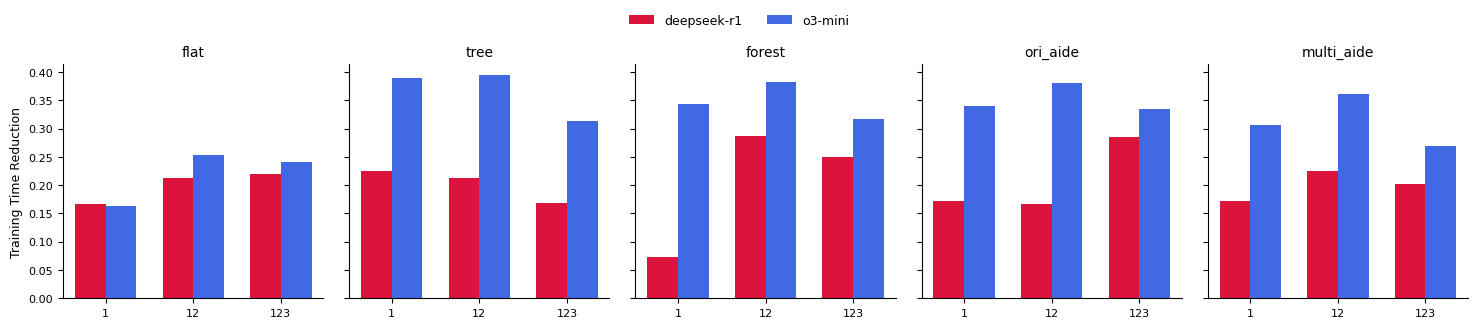

In [50]:
colors = ['crimson', 'royalblue']
x_labels = [1, 12, 123]
x_values = np.arange(len(x_labels))
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
w = 0.35

for idx, search_algo in enumerate(['flat', 'tree', 'forest', 'ori_aide', 'multi_aide']):
    filtered_figure_data = {k: v for k, v in average_reduction_percentage_all_records.items() if search_algo in k}
    for i, model in enumerate(['deepseek-r1', 'o3-mini']):
        y = [filtered_figure_data[f'{search_algo}_{level}_{model}'] for level in [1, 12, 125]]
        axes[idx].bar(x_values - w/2 + i * w, y, width=w, color=colors[i], label=model if idx == 0 else "")
    
    axes[idx].set_title(search_algo, fontsize=15)
    axes[idx].set_xticks(x_values)
    axes[idx].set_xticklabels(x_labels, fontsize=8)
    axes[idx].tick_params(axis='y', labelsize=8)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    if idx == 0:
        axes[idx].set_ylabel('Training Time Reduction', fontsize=9)

# Shared legend above all plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.5, 1.12))

fig.tight_layout(rect=[0, 0, 1, 1.05])
plt.show()

In [53]:
avg_pass_at_50 = {}
for key in pass_at_50.keys():
    avg_pass_at_50[key] = np.mean(list(pass_at_50[key].values()))

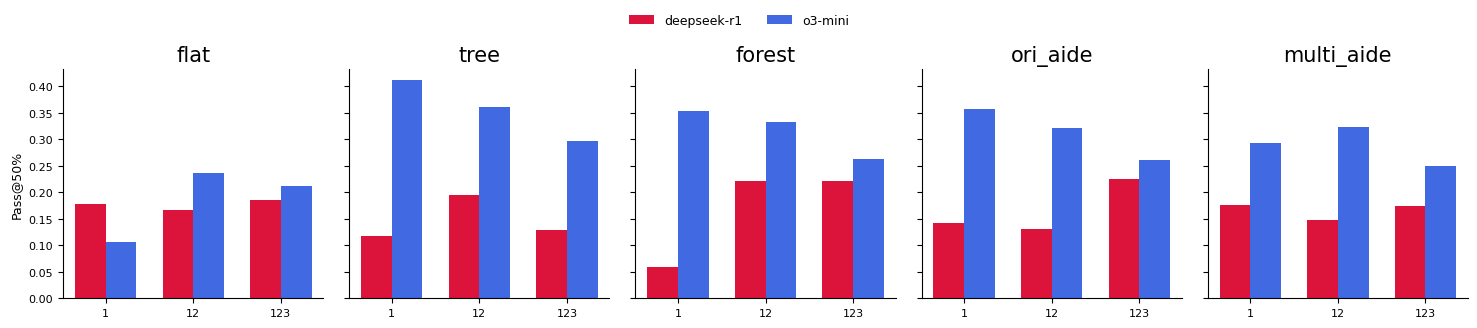

In [54]:
colors = ['crimson', 'royalblue']
x_labels = [1, 12, 123]
x_values = np.arange(len(x_labels))
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
w = 0.35

for idx, search_algo in enumerate(['flat', 'tree', 'forest', 'ori_aide', 'multi_aide']):
    filtered_figure_data = {k: v for k, v in avg_pass_at_50.items() if search_algo in k}
    for i, model in enumerate(['deepseek-r1', 'o3-mini']):
        y = [filtered_figure_data[f'{search_algo}_{level}_{model}'] for level in [1, 12, 125]]
        axes[idx].bar(x_values - w/2 + i * w, y, width=w, color=colors[i], label=model if idx == 0 else "")
    
    axes[idx].set_title(search_algo, fontsize=15)
    axes[idx].set_xticks(x_values)
    axes[idx].set_xticklabels(x_labels, fontsize=8)
    axes[idx].tick_params(axis='y', labelsize=8)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    if idx == 0:
        axes[idx].set_ylabel('Pass@50%', fontsize=9)

# Shared legend above all plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.5, 1.12))

fig.tight_layout(rect=[0, 0, 1, 1.05])
plt.show()